In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\DELL\Downloads\dataset\Daily_Water_Intake.csv")
df

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor
...,...,...,...,...,...,...,...
29995,47,Male,97,3.45,Moderate,Cold,Good
29996,49,Female,109,5.32,High,Hot,Good
29997,56,Female,54,1.50,Moderate,Cold,Poor
29998,36,Male,106,4.00,Low,Hot,Good


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Gender                       30000 non-null  object 
 2   Weight (kg)                  30000 non-null  int64  
 3   Daily Water Intake (liters)  30000 non-null  float64
 4   Physical Activity Level      30000 non-null  object 
 5   Weather                      30000 non-null  object 
 6   Hydration Level              30000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.6+ MB


In [4]:
df.describe()

,Age,Weight (kg),Daily Water Intake (liters)
count,30000.000000,30000.00000,30000.000000
mean,43.467667,76.84860,2.852444
std,14.998940,18.74494,0.835537
min,18.000000,45.00000,1.500000
25%,30.000000,61.00000,2.220000
50%,43.000000,77.00000,2.830000
75%,56.000000,93.00000,3.440000
max,69.000000,109.00000,5.430000


In [5]:
df.duplicated().sum()

np.int64(338)

In [6]:
df = df.drop_duplicates()

In [7]:
df.shape

(29662, 7)

In [8]:
df.isnull().sum()


Age                            0
Gender                         0
Weight (kg)                    0
Daily Water Intake (liters)    0
Physical Activity Level        0
Weather                        0
Hydration Level                0
dtype: int64

In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
categorical_cols = df.select_dtypes(include=['object'])

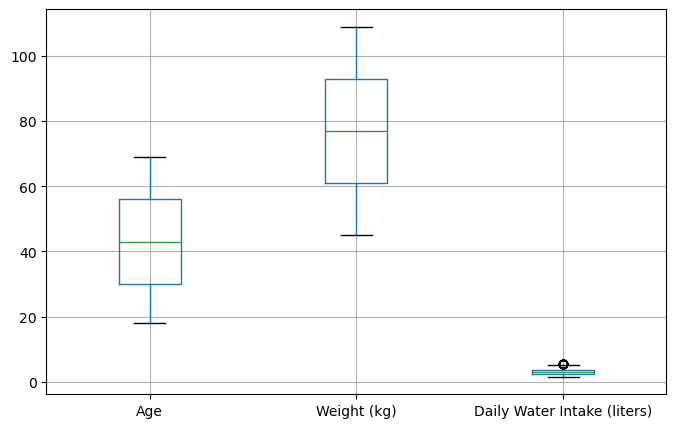

In [10]:
import matplotlib.pyplot as plt

numeric_cols.boxplot(figsize=(8,5))
plt.show()

<Figure size 800x500 with 0 Axes>

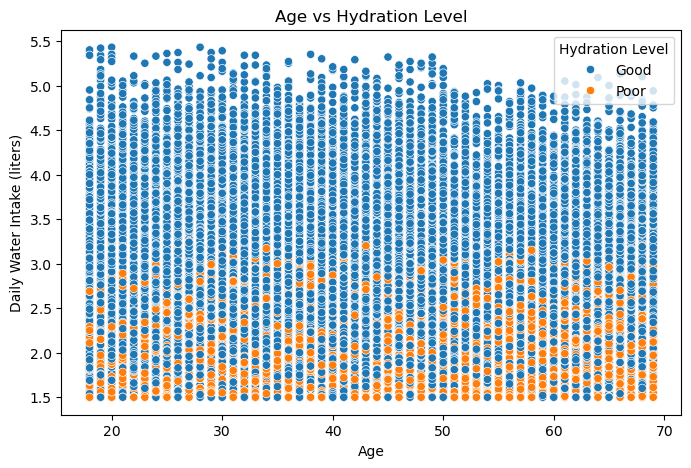

In [12]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Daily Water Intake (liters)', hue='Hydration Level')
plt.title('Age vs Hydration Level')
plt.show()



In [14]:
import pandas as pd
cols = ['Age', 'Weight (kg)', 'Daily Water Intake (liters)']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"Column: {col}")
    print(f" - IQR: {IQR}")
    print(f" - Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f" - Number of outliers detected: {len(outliers)}\n")



Column: Age
 - IQR: 26.0
 - Bounds: [-9.00, 95.00]
 - Number of outliers detected: 0

Column: Weight (kg)
 - IQR: 32.0
 - Bounds: [13.00, 141.00]
 - Number of outliers detected: 0

Column: Daily Water Intake (liters)
 - IQR: 1.2200000000000002
 - Bounds: [0.40, 5.28]
 - Number of outliers detected: 23



In [15]:
df = pd.get_dummies(df, columns=['Physical Activity Level','Weather'], dtype=int)


In [19]:
import numpy as np
from sklearn.impute import KNNImputer
df['Gender'] = df['Gender'].replace('', np.nan).map({'Male': 0, 'Female': 1})

In [21]:
import numpy as np
from sklearn.impute import KNNImputer
df['Hydration Level'] = df['Hydration Level'].replace('', np.nan).map({'Poor': 0, 'Good': 1})

In [22]:
df

,Age,Gender,Weight (kg),Daily Water Intake (liters),Hydration Level,Physical Activity Level_High,Physical Activity Level_Low,Physical Activity Level_Moderate,Weather_Cold,Weather_Hot,Weather_Normal
0,56,0,96,4.23,1,0,0,1,0,1,0
1,60,0,105,3.95,1,1,0,0,0,0,1
2,36,0,68,2.39,1,0,0,1,1,0,0
3,19,1,74,3.13,1,0,0,1,0,1,0
4,38,0,77,2.11,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
29995,47,0,97,3.45,1,0,0,1,1,0,0
29996,49,1,109,5.32,1,1,0,0,0,1,0
29997,56,1,54,1.50,0,0,0,1,1,0,0
29998,36,0,106,4.00,1,0,1,0,0,1,0


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop(columns=['Hydration Level'])
y = df['Hydration Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [24]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


In [25]:
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))


Model Accuracy: 97.02%
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1822
           1       0.98      0.98      0.98      7077

    accuracy                           0.97      8899
   macro avg       0.95      0.96      0.95      8899
weighted avg       0.97      0.97      0.97      8899

